# NHANES Liver Model + Ontology Matching

This notebook builds a **Liver Function model** from NHANES lab-result files and matches it with your ontology/UI features.

**UI Features:**
- ALT (U/L)
- AST (U/L)
- ALP (U/L)
- Bilirubin (mg/dL)
- Albumin (g/dL)
- GGT (U/L)

**Model Output:**
- `Normal_Liver_Profile`
- `Possible_Mild_Liver_Dysfunction`
- `Possible_Severe_Liver_Dysfunction`

> Important: this is a **clinical decision support model**, not a final medical diagnosis.


In [5]:
# 1) Import libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

import matplotlib.pyplot as plt
import joblib
from pathlib import Path

RANDOM_STATE = 42


## 2) Load NHANES files

We use:
- `BIOPRO_L.xpt`: liver lab tests like ALT, AST, ALP, Bilirubin, Albumin, GGT
- `DEMO_L.xpt`: age and gender

All files should be from the same NHANES cycle: **2021–2023**.


In [6]:
# Change paths if needed
BIOPRO_PATH = "BIOPRO_L (1).xpt"   # or BIOPRO_L.xpt
DEMO_PATH = "DEMO_L.xpt"        # or DEMO_L.xpt

# If you run this notebook in another folder, put the xpt files beside the notebook
bio = pd.read_sas(BIOPRO_PATH)
demo = pd.read_sas(DEMO_PATH)

print("BIOPRO shape:", bio.shape)
print("DEMO shape:", demo.shape)
print("BIOPRO columns:")
print(bio.columns.tolist())


BIOPRO shape: (7199, 42)
DEMO shape: (11933, 27)
BIOPRO columns:
['SEQN', 'WTPH2YR', 'LBXSATSI', 'LBXSAL', 'LBDSALSI', 'LBXSAPSI', 'LBXSASSI', 'LBXSC3SI', 'LBXSBU', 'LBDSBUSI', 'LBXSCLSI', 'LBXSCK', 'LBXSCR', 'LBDSCRSI', 'LBXSGB', 'LBDSGBSI', 'LBXSGL', 'LBDSGLSI', 'LBXSGTSI', 'LBDSGTLC', 'LBXSIR', 'LBDSIRSI', 'LBXSLDSI', 'LBXMAGN', 'LBXSOSSI', 'LBXSPH', 'LBDSPHSI', 'LBXSKSI', 'LBXSNASI', 'LBXSTB', 'LBDSTBSI', 'LBDSTBLC', 'LBXSCA', 'LBDSCASI', 'LBXSCH', 'LBDSCHSI', 'LBXSTP', 'LBDSTPSI', 'LBXSTR', 'LBDSTRSI', 'LBXSUA', 'LBDSUASI']


## 3) Select columns that match the UI and ontology

| UI Feature | NHANES Column |
|---|---|
| ALT | `LBXSATSI` |
| AST | `LBXSASSI` |
| ALP | `LBXSAPSI` |
| Bilirubin | `LBXSTB` |
| Albumin | `LBXSAL` |
| GGT | `LBXSGTSI` |
| Age | `RIDAGEYR` |
| Gender | `RIAGENDR` |


In [7]:
liver_cols = [
    "SEQN",
    "LBXSATSI",  # ALT
    "LBXSASSI",  # AST
    "LBXSAPSI",  # ALP
    "LBXSTB",    # Total Bilirubin
    "LBXSAL",    # Albumin
    "LBXSGTSI",  # GGT
]

demo_cols = ["SEQN", "RIDAGEYR", "RIAGENDR"]

bio_liver = bio[liver_cols].copy()
demo_small = demo[demo_cols].copy()

df = bio_liver.merge(demo_small, on="SEQN", how="inner")

# Rename columns to readable names
rename_map = {
    "LBXSATSI": "ALT",
    "LBXSASSI": "AST",
    "LBXSAPSI": "ALP",
    "LBXSTB": "Bilirubin",
    "LBXSAL": "Albumin",
    "LBXSGTSI": "GGT",
    "RIDAGEYR": "Age",
    "RIAGENDR": "Gender"
}

df = df.rename(columns=rename_map)
print(df.head())
print(df.shape)


       SEQN   ALT   AST    ALP  Bilirubin  Albumin   GGT   Age  Gender
0  130378.0  39.0  25.0   91.0        0.7      4.3  41.0  43.0     1.0
1  130379.0  17.0  20.0   64.0        0.7      3.9  31.0  66.0     1.0
2  130380.0  13.0  15.0   78.0        0.6      3.7  44.0  44.0     2.0
3  130386.0  34.0  20.0   54.0        0.5      4.3  28.0  34.0     1.0
4  130387.0  12.0  13.0  116.0        0.3      3.7  17.0  68.0     2.0
(7199, 9)


## 4) Basic cleaning

We remove rows with missing values in the model features and filter impossible values only.  
We do **not** remove abnormal medical values because those are important for the model.


In [8]:
features = ["ALT", "AST", "ALP", "Bilirubin", "Albumin", "GGT", "Age", "Gender"]

# Drop missing values in selected features
df = df.dropna(subset=features).copy()

# Keep only realistic positive lab values
df = df[
    (df["ALT"] > 0) &
    (df["AST"] > 0) &
    (df["ALP"] > 0) &
    (df["Bilirubin"] > 0) &
    (df["Albumin"] > 0) &
    (df["GGT"] > 0) &
    (df["Age"] >= 18)
].copy()

print(df.shape)
df[features].describe()


(5639, 9)


,ALT,AST,ALP,Bilirubin,Albumin,GGT,Age,Gender
count,5639.000000,5639.000000,5639.000000,5639.000000,5639.000000,5639.000000,5639.000000,5639.000000
mean,21.702784,22.512148,84.826742,0.499278,4.074056,29.658982,52.650115,1.546551
std,16.421505,14.587937,28.312394,0.394460,0.353248,46.049777,18.047446,0.497872
min,3.000000,6.000000,20.000000,0.110000,2.200000,2.000000,18.000000,1.000000
25%,13.000000,16.000000,66.000000,0.300000,3.900000,13.000000,37.000000,1.000000
50%,18.000000,20.000000,80.000000,0.400000,4.100000,20.000000,56.000000,2.000000
75%,25.000000,25.000000,98.000000,0.600000,4.300000,31.000000,68.000000,2.000000
max,350.000000,518.000000,458.000000,14.200000,5.500000,1541.000000,80.000000,2.000000


## 5) Create medical findings for ontology

These findings can be mapped directly to your ontology classes.

Example:
- `High_ALT`
- `High_AST`
- `High_ALP`
- `High_Bilirubin`
- `Low_Albumin`
- `High_GGT`


In [9]:
def liver_findings(row):
    findings = []

    # Simple adult reference-style thresholds for project use
    if row["ALT"] > 40:
        findings.append("High_ALT")
    if row["AST"] > 40:
        findings.append("High_AST")
    if row["ALP"] > 120:
        findings.append("High_ALP")
    if row["Bilirubin"] > 1.2:
        findings.append("High_Bilirubin")
    if row["Albumin"] < 3.5:
        findings.append("Low_Albumin")
    if row["GGT"] > 60:
        findings.append("High_GGT")

    if not findings:
        findings.append("Normal_Liver_Lab_Profile")

    return findings

df["ontology_findings"] = df.apply(liver_findings, axis=1)
df[["ALT", "AST", "ALP", "Bilirubin", "Albumin", "GGT", "ontology_findings"]].head()


,ALT,AST,ALP,Bilirubin,Albumin,GGT,ontology_findings
0,39.0,25.0,91.0,0.7,4.3,41.0,[Normal_Liver_Lab_Profile]
1,17.0,20.0,64.0,0.7,3.9,31.0,[Normal_Liver_Lab_Profile]
2,13.0,15.0,78.0,0.6,3.7,44.0,[Normal_Liver_Lab_Profile]
3,34.0,20.0,54.0,0.5,4.3,28.0,[Normal_Liver_Lab_Profile]
4,12.0,13.0,116.0,0.3,3.7,17.0,[Normal_Liver_Lab_Profile]


## 6) Build the target label

Because NHANES lab files do not provide a ready-made `liver diagnosis` label, we create a **rule-based clinical target** from liver lab thresholds.

This is useful because the ML model and ontology will use the same medical logic.


In [10]:
def liver_target(row):
    findings = liver_findings(row)
    finding_set = set(findings)

    severe_conditions = [
        row["Bilirubin"] > 2.0,
        row["Albumin"] < 3.0,
        row["ALT"] > 120,
        row["AST"] > 120,
        row["GGT"] > 180,
        len(finding_set - {"Normal_Liver_Lab_Profile"}) >= 3
    ]

    mild_conditions = [
        "High_ALT" in finding_set,
        "High_AST" in finding_set,
        "High_ALP" in finding_set,
        "High_Bilirubin" in finding_set,
        "Low_Albumin" in finding_set,
        "High_GGT" in finding_set
    ]

    if any(severe_conditions):
        return "Possible_Severe_Liver_Dysfunction"
    elif any(mild_conditions):
        return "Possible_Mild_Liver_Dysfunction"
    else:
        return "Normal_Liver_Profile"


df["target"] = df.apply(liver_target, axis=1)
print(df["target"].value_counts())


target
Normal_Liver_Profile                 4296
Possible_Mild_Liver_Dysfunction      1132
Possible_Severe_Liver_Dysfunction     211
Name: count, dtype: int64


## 7) Prepare X and y

We will train the model on the same features used in the UI.


In [11]:
model_features = ["ALT", "AST", "ALP", "Bilirubin", "Albumin", "GGT"]

X = df[model_features].copy()
y = df["target"].copy()

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Classes:", list(label_encoder.classes_))


Classes: ['Normal_Liver_Profile', 'Possible_Mild_Liver_Dysfunction', 'Possible_Severe_Liver_Dysfunction']


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_encoded
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)


Train: (4511, 6)
Test: (1128, 6)


## 8) Train 4 models and compare them

We compare:
1. Logistic Regression
2. Decision Tree
3. Random Forest
4. Gradient Boosting


In [13]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE))
    ]),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=RANDOM_STATE
    )
}

results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision_macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "Recall_macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "F1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "F1_weighted": f1_score(y_test, y_pred, average="weighted", zero_division=0)
    })
    trained_models[name] = model

results_df = pd.DataFrame(results).sort_values(by="F1_macro", ascending=False)
results_df


,Model,Accuracy,Precision_macro,Recall_macro,F1_macro,F1_weighted
3,Gradient Boosting,0.997340,0.995652,0.976190,0.985466,0.997300
2,Random Forest,0.990248,0.968132,0.925635,0.944427,0.989879
1,Decision Tree,0.944149,0.855942,0.882754,0.868539,0.944614
0,Logistic Regression,0.788121,0.636951,0.789566,0.685931,0.804674


## 9) Select the best model

For medical classification, **recall and F1-score** are often more important than accuracy alone.
Here we choose the best model using `F1_macro`.


In [14]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print("Best model:", best_model_name)

best_pred = best_model.predict(X_test)
print(classification_report(y_test, best_pred, target_names=label_encoder.classes_, zero_division=0))


Best model: Gradient Boosting
                                   precision    recall  f1-score   support

             Normal_Liver_Profile       1.00      1.00      1.00       859
  Possible_Mild_Liver_Dysfunction       0.99      1.00      0.99       227
Possible_Severe_Liver_Dysfunction       1.00      0.93      0.96        42

                         accuracy                           1.00      1128
                        macro avg       1.00      0.98      0.99      1128
                     weighted avg       1.00      1.00      1.00      1128



[[859   0   0]
 [  0 227   0]
 [  0   3  39]]


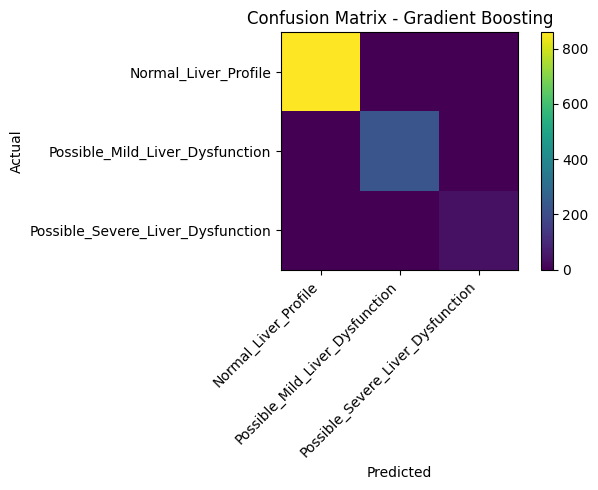

In [15]:
cm = confusion_matrix(y_test, best_pred)
print(cm)

plt.figure(figsize=(7, 5))
plt.imshow(cm)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(range(len(label_encoder.classes_)), label_encoder.classes_, rotation=45, ha="right")
plt.yticks(range(len(label_encoder.classes_)), label_encoder.classes_)
plt.colorbar()
plt.tight_layout()
plt.show()


## 10) Feature importance

Feature importance helps explain which lab tests affected the model most.


In [16]:
def get_feature_importance(model, feature_names):
    # For pipelines, get the final model
    if hasattr(model, "named_steps"):
        final_model = model.named_steps["model"]
    else:
        final_model = model

    if hasattr(final_model, "feature_importances_"):
        return pd.DataFrame({
            "Feature": feature_names,
            "Importance": final_model.feature_importances_
        }).sort_values(by="Importance", ascending=False)

    if hasattr(final_model, "coef_"):
        importance = np.mean(np.abs(final_model.coef_), axis=0)
        return pd.DataFrame({
            "Feature": feature_names,
            "Importance": importance
        }).sort_values(by="Importance", ascending=False)

    return None

importance_df = get_feature_importance(best_model, model_features)
importance_df


,Feature,Importance
2,ALP,0.249335
0,ALT,0.221735
5,GGT,0.207469
4,Albumin,0.152668
1,AST,0.091155
3,Bilirubin,0.077638


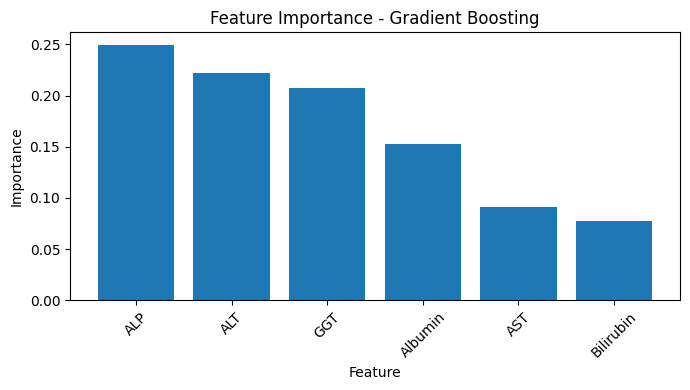

In [17]:
if importance_df is not None:
    plt.figure(figsize=(7, 4))
    plt.bar(importance_df["Feature"], importance_df["Importance"])
    plt.title(f"Feature Importance - {best_model_name}")
    plt.xlabel("Feature")
    plt.ylabel("Importance")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


## 11) Prediction function for FastAPI / Streamlit

This function takes the same values from the UI and returns:
- predicted class
- probabilities
- ontology findings


In [18]:
def predict_liver_case(ALT, AST, ALP, Bilirubin, Albumin, GGT):
    case = pd.DataFrame([{
        "ALT": ALT,
        "AST": AST,
        "ALP": ALP,
        "Bilirubin": Bilirubin,
        "Albumin": Albumin,
        "GGT": GGT
    }])

    pred_encoded = best_model.predict(case)[0]
    pred_label = label_encoder.inverse_transform([pred_encoded])[0]

    if hasattr(best_model, "predict_proba"):
        probs = best_model.predict_proba(case)[0]
    else:
        probs = np.zeros(len(label_encoder.classes_))

    temp_row = case.iloc[0]
    findings = liver_findings(temp_row)

    probabilities = {
        label_encoder.classes_[i]: round(float(probs[i]) * 100, 2)
        for i in range(len(label_encoder.classes_))
    }

    return {
        "prediction": pred_label,
        "probabilities_percent": probabilities,
        "ontology_findings": findings,
        "recommended_tests": ["Repeat Liver Function Test", "Viral Hepatitis Markers", "Abdominal Ultrasound"],
        "specialist": "Hepatologist / Gastroenterologist"
    }

predict_liver_case(
    ALT=65,
    AST=55,
    ALP=140,
    Bilirubin=1.5,
    Albumin=3.8,
    GGT=85
)


{'prediction': 'Possible_Severe_Liver_Dysfunction',
 'probabilities_percent': {'Normal_Liver_Profile': 0.0,
  'Possible_Mild_Liver_Dysfunction': 0.0,
  'Possible_Severe_Liver_Dysfunction': 100.0},
 'ontology_findings': ['High_ALT',
  'High_AST',
  'High_ALP',
  'High_Bilirubin',
  'High_GGT'],
 'recommended_tests': ['Repeat Liver Function Test',
  'Viral Hepatitis Markers',
  'Abdominal Ultrasound'],
 'specialist': 'Hepatologist / Gastroenterologist'}

## 12) Save model artifacts

These files can be used later in FastAPI.


In [19]:
output_dir = Path("liver_model_artifacts")
output_dir.mkdir(exist_ok=True)

joblib.dump(best_model, output_dir / "liver_best_model.joblib")
joblib.dump(label_encoder, output_dir / "liver_label_encoder.joblib")
joblib.dump(model_features, output_dir / "liver_feature_columns.joblib")

# Save cleaned data too
df.to_csv(output_dir / "nhanes_liver_cleaned.csv", index=False)
results_df.to_csv(output_dir / "liver_model_comparison.csv", index=False)

print("Saved artifacts in:", output_dir.resolve())


Saved artifacts in: D:\collage y4\finaaal\models\liver model\liver_model_artifacts


# Discussion points for your doctor

You can say:

- I used NHANES real laboratory data from the 2021–2023 cycle.
- I matched the ML input features with the ontology and UI fields.
- I created the target using medical threshold rules because NHANES lab files do not provide a direct liver diagnosis label.
- I compared four machine learning models and selected the best model based on F1-score and recall, not accuracy only.
- The system is designed as a decision-support tool, not a final diagnosis system.
